<a href="https://colab.research.google.com/github/khalid-saqr/picoNewton/blob/main/picoNewton_v4/notebooks/picoNewton_v4_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/khalid-saqr/picoNewton/blob/main/picoNewton_v4/notebooks/picoNewton_v4_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# picoNewton_v4 — full parametric production study

This is the single Google Colab entry point for the six-artery anisotropic Womersley → membrane–cortex → Piezo1 study. Run all cells once from top to bottom in a standard Colab CPU runtime. The notebook creates a unique UTC-stamped Google Drive directory, installs the reviewed package from GitHub, runs the package tests, solves the full-resolution model, executes the declared parameter ensemble, produces Nature-compatible multi-panel figures, and archives all data, provenance, environment metadata, and checksums.

## Scientific question

Does anisotropic near-wall forcing provide mechanosensory information that is distinguishable from wall shear stress across the aortic root, thoracic aorta, femoral, carotid, iliac, and brachial arteries, and are current-based conclusions robust to the declared uncertain membrane and endpoint parameters?

## Vector-resolved membrane and endpoint model

Wall shear stress, signed transverse Lamb force, and nonnegative force exposure remain separate physical inputs. Normal and tangential mechanics are transferred through separate passive viscoelastic branches to apical and junctional membrane domains. Piezo1 current is the primary decision endpoint. The calcium-scale output is exploratory and cannot rescue a failed current decision.

## Full numerical resolution

The production workflow is fixed at radial order 150, 2,048 time points per cardiac cycle, 256 near-wall integration nodes, six arteries, and the complete direct, matched-load, surrogate, anisotropy, harmonic, and elastic control matrix.

## Parametric design

The full hydrodynamics are computed once and archived. A deterministic 13-scenario one-at-a-time ensemble then reuses those exact 2,048-point forcing waveforms and re-solves the membrane and Piezo1 dynamics while varying localization area, force-transfer fraction, channel count, apical channel fraction, fast viscoelastic fraction, and pressure ceiling. The design is declared before execution and is not retuned after results are observed.

## Nature-compatible figures

Each complete multi-panel figure is generated at 183 mm double-column width and below 170 mm height. Text is a standard sans-serif family at 5–7 pt, panel labels are lowercase bold 8 pt, line widths are at least 1 pt, backgrounds are white, and panels are arranged alphabetically. Figures are exported as editable PDF and SVG and as 600 dpi PNG and LZW-compressed TIFF.

## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Run configuration

`REPO_REF="main"` selects the merged production source. The resolved commit SHA is recorded in every run for exact provenance.

In [3]:
REPO_URL = "https://github.com/khalid-saqr/picoNewton.git"
REPO_REF = "main"
PACKAGE_SUBDIR = "picoNewton_v4"
NUMERICAL_PROFILE = "full"
RUN_PACKAGE_TESTS = True

## 3. Create immutable runtime directories

Computation uses local Colab storage for speed. A unique persistent directory is created immediately under `MyDrive/picoNewton_v4_runtime/runs/`, and command logs are mirrored there as they are produced.

In [4]:
from __future__ import annotations

import hashlib
import json
import secrets
import shutil
import subprocess
import sys
import traceback
from datetime import datetime, timezone
from pathlib import Path

RUN_ID = f"{datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S_UTC')}_{secrets.token_hex(2)}"
DRIVE_PARENT = Path("/content/drive/MyDrive/picoNewton_v4_runtime/runs")
DRIVE_RUN_ROOT = DRIVE_PARENT / RUN_ID
LOCAL_ROOT = Path("/content/picoNewton_v4_work") / RUN_ID
REPOSITORY_DIR = LOCAL_ROOT / "repository"
PACKAGE_DIR = REPOSITORY_DIR / PACKAGE_SUBDIR
LOCAL_OUTPUT = LOCAL_ROOT / "production_output"
LOCAL_LOGS = LOCAL_ROOT / "logs"

DRIVE_PARENT.mkdir(parents=True, exist_ok=True)
DRIVE_RUN_ROOT.mkdir(parents=False, exist_ok=False)
(DRIVE_RUN_ROOT / "logs").mkdir(parents=True, exist_ok=True)
LOCAL_LOGS.mkdir(parents=True, exist_ok=True)


def run_logged(command, *, cwd=None, log_name):
    command = [str(item) for item in command]
    print("\n$", " ".join(command), flush=True)
    lines = []
    with subprocess.Popen(
        command,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
    ) as process:
        assert process.stdout is not None
        for line in process.stdout:
            print(line, end="")
            lines.append(line)
        return_code = process.wait()
    text = "".join(lines)
    (LOCAL_LOGS / log_name).write_text(text, encoding="utf-8")
    (DRIVE_RUN_ROOT / "logs" / log_name).write_text(text, encoding="utf-8")
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, command)
    return text


def record_failure(stage, error):
    payload = {
        "stage": stage,
        "run_id": RUN_ID,
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "error_type": type(error).__name__,
        "error": str(error),
        "traceback": traceback.format_exc(),
    }
    (DRIVE_RUN_ROOT / "logs" / "failure.json").write_text(
        json.dumps(payload, indent=2, sort_keys=True) + "\n", encoding="utf-8"
    )

print("Run ID:", RUN_ID)
print("Persistent output:", DRIVE_RUN_ROOT)

Run ID: 20260719_122432_UTC_62d4
Persistent output: /content/drive/MyDrive/picoNewton_v4_runtime/runs/20260719_122432_UTC_62d4


## 4. Clone and install the merged package

The selected GitHub ref is cloned, its resolved commit is recorded, and the editable install uses that exact source tree.

In [8]:
from __future__ import annotations

import importlib
import os
import subprocess
import sys
from pathlib import Path

# Note: Removed the missing 'stage' context manager.
# Using variables defined in the 'runtime' cell:
# REPOSITORY_DIR, PACKAGE_DIR, DRIVE_RUN_ROOT

# Clone only when this run does not already contain a valid checkout.
if not (REPOSITORY_DIR / ".git").is_dir():
    run_logged(
        [
            "git",
            "clone",
            "--branch",
            REPO_REF,
            "--single-branch",
            REPO_URL,
            REPOSITORY_DIR,
        ],
        log_name="git_clone.log",
    )
else:
    print("Reusing existing repository checkout:", REPOSITORY_DIR)

# Synchronize the checkout with the requested remote branch.
run_logged(
    ["git", "fetch", "--force", "origin", REPO_REF],
    log_name="git_fetch.log",
    cwd=REPOSITORY_DIR,
)

run_logged(
    ["git", "checkout", "--detach", "FETCH_HEAD"],
    log_name="git_checkout.log",
    cwd=REPOSITORY_DIR,
)

resolved_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=REPOSITORY_DIR,
    text=True,
).strip()

print("Resolved repository commit:", resolved_commit)

# Use DRIVE_RUN_ROOT from the runtime cell
provenance_dir = DRIVE_RUN_ROOT / "provenance"
provenance_dir.mkdir(parents=True, exist_ok=True)

(provenance_dir / "git_commit.txt").write_text(
    resolved_commit + "\n",
    encoding="utf-8",
)

# Install the package and development dependencies.
run_logged(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-cache-dir",
        "-e",
        f"{PACKAGE_DIR}[dev]",
    ],
    log_name="pip_install.log",
)

# The project uses a src/ package layout.
SOURCE_DIR = (PACKAGE_DIR / "src").resolve()
PACKAGE_INIT = SOURCE_DIR / "piconewton_v4" / "__init__.py"

if not PACKAGE_INIT.is_file():
    raise FileNotFoundError(
        "The installed package source was not found:\n"
        f"  expected: {PACKAGE_INIT}"
    )

source_string = str(SOURCE_DIR)

if source_string not in sys.path:
    sys.path.insert(0, source_string)

# Also expose it to Python subprocesses launched later by the notebook.
existing_pythonpath = os.environ.get("PYTHONPATH", "")
pythonpath_entries = [
    entry
    for entry in existing_pythonpath.split(os.pathsep)
    if entry
]

if source_string not in pythonpath_entries:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [source_string, *pythonpath_entries]
    )

# Prevent an earlier failed or stale import from remaining cached.
for module_name in list(sys.modules):
    if (
        module_name == "piconewton_v4"
        or module_name.startswith("piconewton_v4.")
    ):
        del sys.modules[module_name]

importlib.invalidate_caches()

import piconewton_v4
from piconewton_v4.scientific_study import run_scientific_study
from piconewton_v4.workflow import run_workflow

imported_from = Path(piconewton_v4.__file__).resolve()

if SOURCE_DIR not in imported_from.parents:
    raise ImportError(
        "The wrong piconewton_v4 installation was imported.\n"
        f"  imported from: {imported_from}\n"
        f"  expected under: {SOURCE_DIR}"
    )

# Verify that a fresh Python process also sees the installation.
fresh_import = subprocess.run(
    [
        sys.executable,
        "-c",
        (
            "import pathlib, piconewton_v4; "
            "print(pathlib.Path(piconewton_v4.__file__).resolve())"
        ),
    ],
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    check=False,
    env=os.environ.copy(),
)

print("Fresh-process import check:")
print(fresh_import.stdout)

if fresh_import.returncode != 0:
    raise RuntimeError(
        "piconewton_v4 could not be imported by a fresh Python process."
    )

print("Package import passed.")
print("Imported from:", imported_from)

Reusing existing repository checkout: /content/picoNewton_v4_work/20260719_122432_UTC_62d4/repository

$ git fetch --force origin main
From https://github.com/khalid-saqr/picoNewton
 * branch            main       -> FETCH_HEAD

$ git checkout --detach FETCH_HEAD
HEAD is now at ca89b2a Merge pull request #8 from khalid-saqr/agent/final-colab-parametric-nature-figures
Resolved repository commit: ca89b2af7e9d161a24909d847ca168b91d2270c1

$ /usr/bin/python3 -m pip install --no-cache-dir -e /content/picoNewton_v4_work/20260719_122432_UTC_62d4/repository/picoNewton_v4[dev]
Obtaining file:///content/picoNewton_v4_work/20260719_122432_UTC_62d4/repository/picoNewton_v4
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build edit

## 5. Run the package test suite

The model is not executed unless the repository tests pass. The complete pytest output is stored in Drive.

In [9]:
try:
    if RUN_PACKAGE_TESTS:
        run_logged([sys.executable, "-m", "pytest", "-q", "-ra"], cwd=PACKAGE_DIR, log_name="pytest.log")
        print("All package tests passed.")
except Exception as error:
    record_failure("tests", error)
    raise


$ /usr/bin/python3 -m pytest -q -ra
..................                                                       [100%]
All package tests passed.


## 6. Execute the full parametric production workflow

The repository script runs the full current-primary scientific study, the 13-scenario full-resolution membrane–Piezo1 ensemble, three Nature-compatible multi-panel figures, figure legends, provenance, environment capture, and SHA-256 checksums.

In [10]:
try:
    PRODUCTION_SCRIPT = PACKAGE_DIR / "scripts" / "run_colab_production.py"
    if not PRODUCTION_SCRIPT.is_file():
        raise FileNotFoundError(PRODUCTION_SCRIPT)
    run_logged([
        sys.executable,
        PRODUCTION_SCRIPT,
        "--package-root", PACKAGE_DIR,
        "--output", LOCAL_OUTPUT,
        "--profile", NUMERICAL_PROFILE,
        "--repository-commit", resolved_commit,  # Changed from RESOLVED_COMMIT
    ], cwd=PACKAGE_DIR, log_name="production.log")
except Exception as error:
    record_failure("production", error)
    raise


$ /usr/bin/python3 /content/picoNewton_v4_work/20260719_122432_UTC_62d4/repository/picoNewton_v4/scripts/run_colab_production.py --package-root /content/picoNewton_v4_work/20260719_122432_UTC_62d4/repository/picoNewton_v4 --output /content/picoNewton_v4_work/20260719_122432_UTC_62d4/production_output --profile full --repository-commit ca89b2af7e9d161a24909d847ca168b91d2270c1
Parameter scenario 01/13: baseline
Parameter scenario 02/13: area_0p5
Parameter scenario 03/13: area_3
Parameter scenario 04/13: transfer_0p1
Parameter scenario 05/13: transfer_0p3
Parameter scenario 06/13: channels_1000
Parameter scenario 07/13: channels_10000
Parameter scenario 08/13: apical_0p25
Parameter scenario 09/13: apical_0p75
Parameter scenario 10/13: fast_0p25
Parameter scenario 11/13: fast_0p75
Parameter scenario 12/13: ceiling_35
Parameter scenario 13/13: ceiling_140
{
  "checksummed_files": 39,
  "claims_enabled": false,
  "completed_utc": "2026-07-19T12:32:00.315684+00:00",
  "elapsed_s": 77.6351644

## 7. Validate the completed local run

In [13]:
required = (
    LOCAL_OUTPUT / "FINAL_MANIFEST.json",
    LOCAL_OUTPUT / "SHA256SUMS.json",
    LOCAL_OUTPUT / "scientific_study" / "model_outputs" / "six_artery_summary.csv",
    LOCAL_OUTPUT / "scientific_study" / "assessment" / "primary_current_decisions.csv",
    LOCAL_OUTPUT / "scientific_study" / "assessment" / "scientific_assessment.json",
    LOCAL_OUTPUT / "scientific_study" / "hydrodynamics" / "physical_forcing_waveforms.npz",
    LOCAL_OUTPUT / "parameter_study" / "parameter_scenarios.csv",
    LOCAL_OUTPUT / "parameter_study" / "parametric_artery_results.csv",
    LOCAL_OUTPUT / "parameter_study" / "parameter_scenario_summary.csv",
    LOCAL_OUTPUT / "parameter_study" / "parametric_current_waveforms.npz",
    LOCAL_OUTPUT / "figures" / "Figure_1_forcing_and_baseline_response.pdf",
    LOCAL_OUTPUT / "figures" / "Figure_2_current_primary_assessment.pdf",
    LOCAL_OUTPUT / "figures" / "Figure_3_parametric_robustness.pdf",
)
missing = [path for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError("Missing production outputs:\n" + "\n".join(str(path) for path in missing))
manifest = json.loads((LOCAL_OUTPUT / "FINAL_MANIFEST.json").read_text())
if manifest.get("status") != "completed_with_claims_disabled":
    raise RuntimeError(json.dumps(manifest, indent=2, sort_keys=True))
if manifest.get("package_commit") != resolved_commit:  # Changed from RESOLVED_COMMIT
    raise RuntimeError("Manifest commit does not match the cloned repository")
if manifest.get("parameter_scenarios") != 13 or manifest.get("parameter_artery_rows") != 78:
    raise RuntimeError("Parametric output dimensions are incorrect")
print("Local production run validated.")

Local production run validated.


## 8. Inspect principal current and parameter tables

In [15]:
import pandas as pd
from IPython.display import display

current_decisions = pd.read_csv(LOCAL_OUTPUT / "scientific_study" / "assessment" / "primary_current_decisions.csv")
parameter_summary = pd.read_csv(LOCAL_OUTPUT / "parameter_study" / "parameter_scenario_summary.csv")
print("Current-primary hypothesis decisions")
display(current_decisions)
print("Parameter scenario summary")
display(parameter_summary)

Current-primary hypothesis decisions


,hypothesis,target,passing_arteries,current_passing_arteries,calcium_passing_arteries,required_arteries,primary_endpoint,decision,current_threshold_pa,calcium_threshold_nm,calcium_interpretation
0,H3a,exposure,2,2,6,4,current,fail,3.3,10.0,exploratory_uncalibrated
1,H3a,signed,0,0,6,4,current,fail,3.3,10.0,exploratory_uncalibrated
2,H3a_peak_matched,exposure_peak_matched,0,0,6,4,current,fail,3.3,10.0,exploratory_uncalibrated
3,H3a_peak_matched,signed_peak_matched,0,0,6,4,current,fail,3.3,10.0,exploratory_uncalibrated
4,H3a_rms_matched,exposure_rms_matched,0,0,6,4,current,fail,3.3,10.0,exploratory_uncalibrated
5,H3a_rms_matched,signed_rms_matched,0,0,6,4,current,fail,3.3,10.0,exploratory_uncalibrated
6,H3a_work_matched,exposure_work_matched,0,0,6,4,current,fail,3.3,10.0,exploratory_uncalibrated
7,H3a_work_matched,signed_work_matched,0,0,6,4,current,fail,3.3,10.0,exploratory_uncalibrated
8,H3b,actual_exposure,0,0,6,4,current,fail,3.3,10.0,exploratory_uncalibrated
9,H3b,actual_signed,0,0,6,4,current,fail,3.3,10.0,exploratory_uncalibrated


Parameter scenario summary


,scenario_id,varied_parameter,varied_value,signed_passing_arteries,exposure_passing_arteries,signed_median_h3_current_difference_pa,exposure_median_h3_current_difference_pa,signed_maximum_h3_current_difference_pa,exposure_maximum_h3_current_difference_pa,maximum_primary_clipped_fraction,maximum_signed_exposure_current_difference_pa,localization_area_um2,force_transfer_fraction,channel_count,apical_channel_fraction,fast_fraction,maximum_pressure_mmhg,signed_cross_artery_pass,exposure_cross_artery_pass
0,apical_0p25,apical_channel_fraction,0.25,1,6,3.075699,4.956335,4.004383,5.750277,0.131348,2.287733e+00,10.0,1.0,4165.0,0.25,0.50,70.0,False,True
1,apical_0p75,apical_channel_fraction,0.75,0,0,1.025233,1.507746,1.334794,3.169955,0.131348,2.287733e+00,10.0,1.0,4165.0,0.75,0.50,70.0,False,False
2,area_0p5,localization_area_um2,0.50,0,0,2.410119,0.571394,2.561613,0.681831,1.000000,6.443996e-09,0.5,1.0,4165.0,0.50,0.50,70.0,False,False
3,area_3,localization_area_um2,3.00,0,0,1.469815,2.487232,1.700773,2.784255,0.421875,6.913055e-08,3.0,1.0,4165.0,0.50,0.50,70.0,False,False
4,baseline,baseline,NaN,0,2,2.050466,3.114063,2.669589,3.753959,0.131348,4.655007e-08,10.0,1.0,4165.0,0.50,0.50,70.0,False,False
5,ceiling_140,maximum_pressure_mmhg,140.00,0,2,2.050466,3.114063,2.670205,3.827091,0.000000,4.655007e-08,10.0,1.0,4165.0,0.50,0.50,140.0,False,False
6,ceiling_35,maximum_pressure_mmhg,35.00,0,0,2.014966,2.542995,2.398076,2.783933,0.686523,4.655007e-08,10.0,1.0,4165.0,0.50,0.50,35.0,False,False
7,channels_1000,channel_count,1000.00,0,0,0.492309,0.747674,0.640958,0.901311,0.131348,1.117649e-08,10.0,1.0,1000.0,0.50,0.50,70.0,False,False
8,channels_10000,channel_count,10000.00,6,6,4.923088,7.476741,6.409577,9.013108,0.131348,1.117649e-07,10.0,1.0,10000.0,0.50,0.50,70.0,True,True
9,fast_0p25,fast_fraction,0.25,0,2,2.006500,3.110522,2.350483,3.649785,0.094238,4.580338e-08,10.0,1.0,4165.0,0.50,0.25,70.0,False,False


## 9. Preview complete multi-panel figures

The displayed PNG files are previews. The Drive archive also contains editable PDF and SVG files and 600 dpi TIFF files for submission.

Figure_1_forcing_and_baseline_response.png


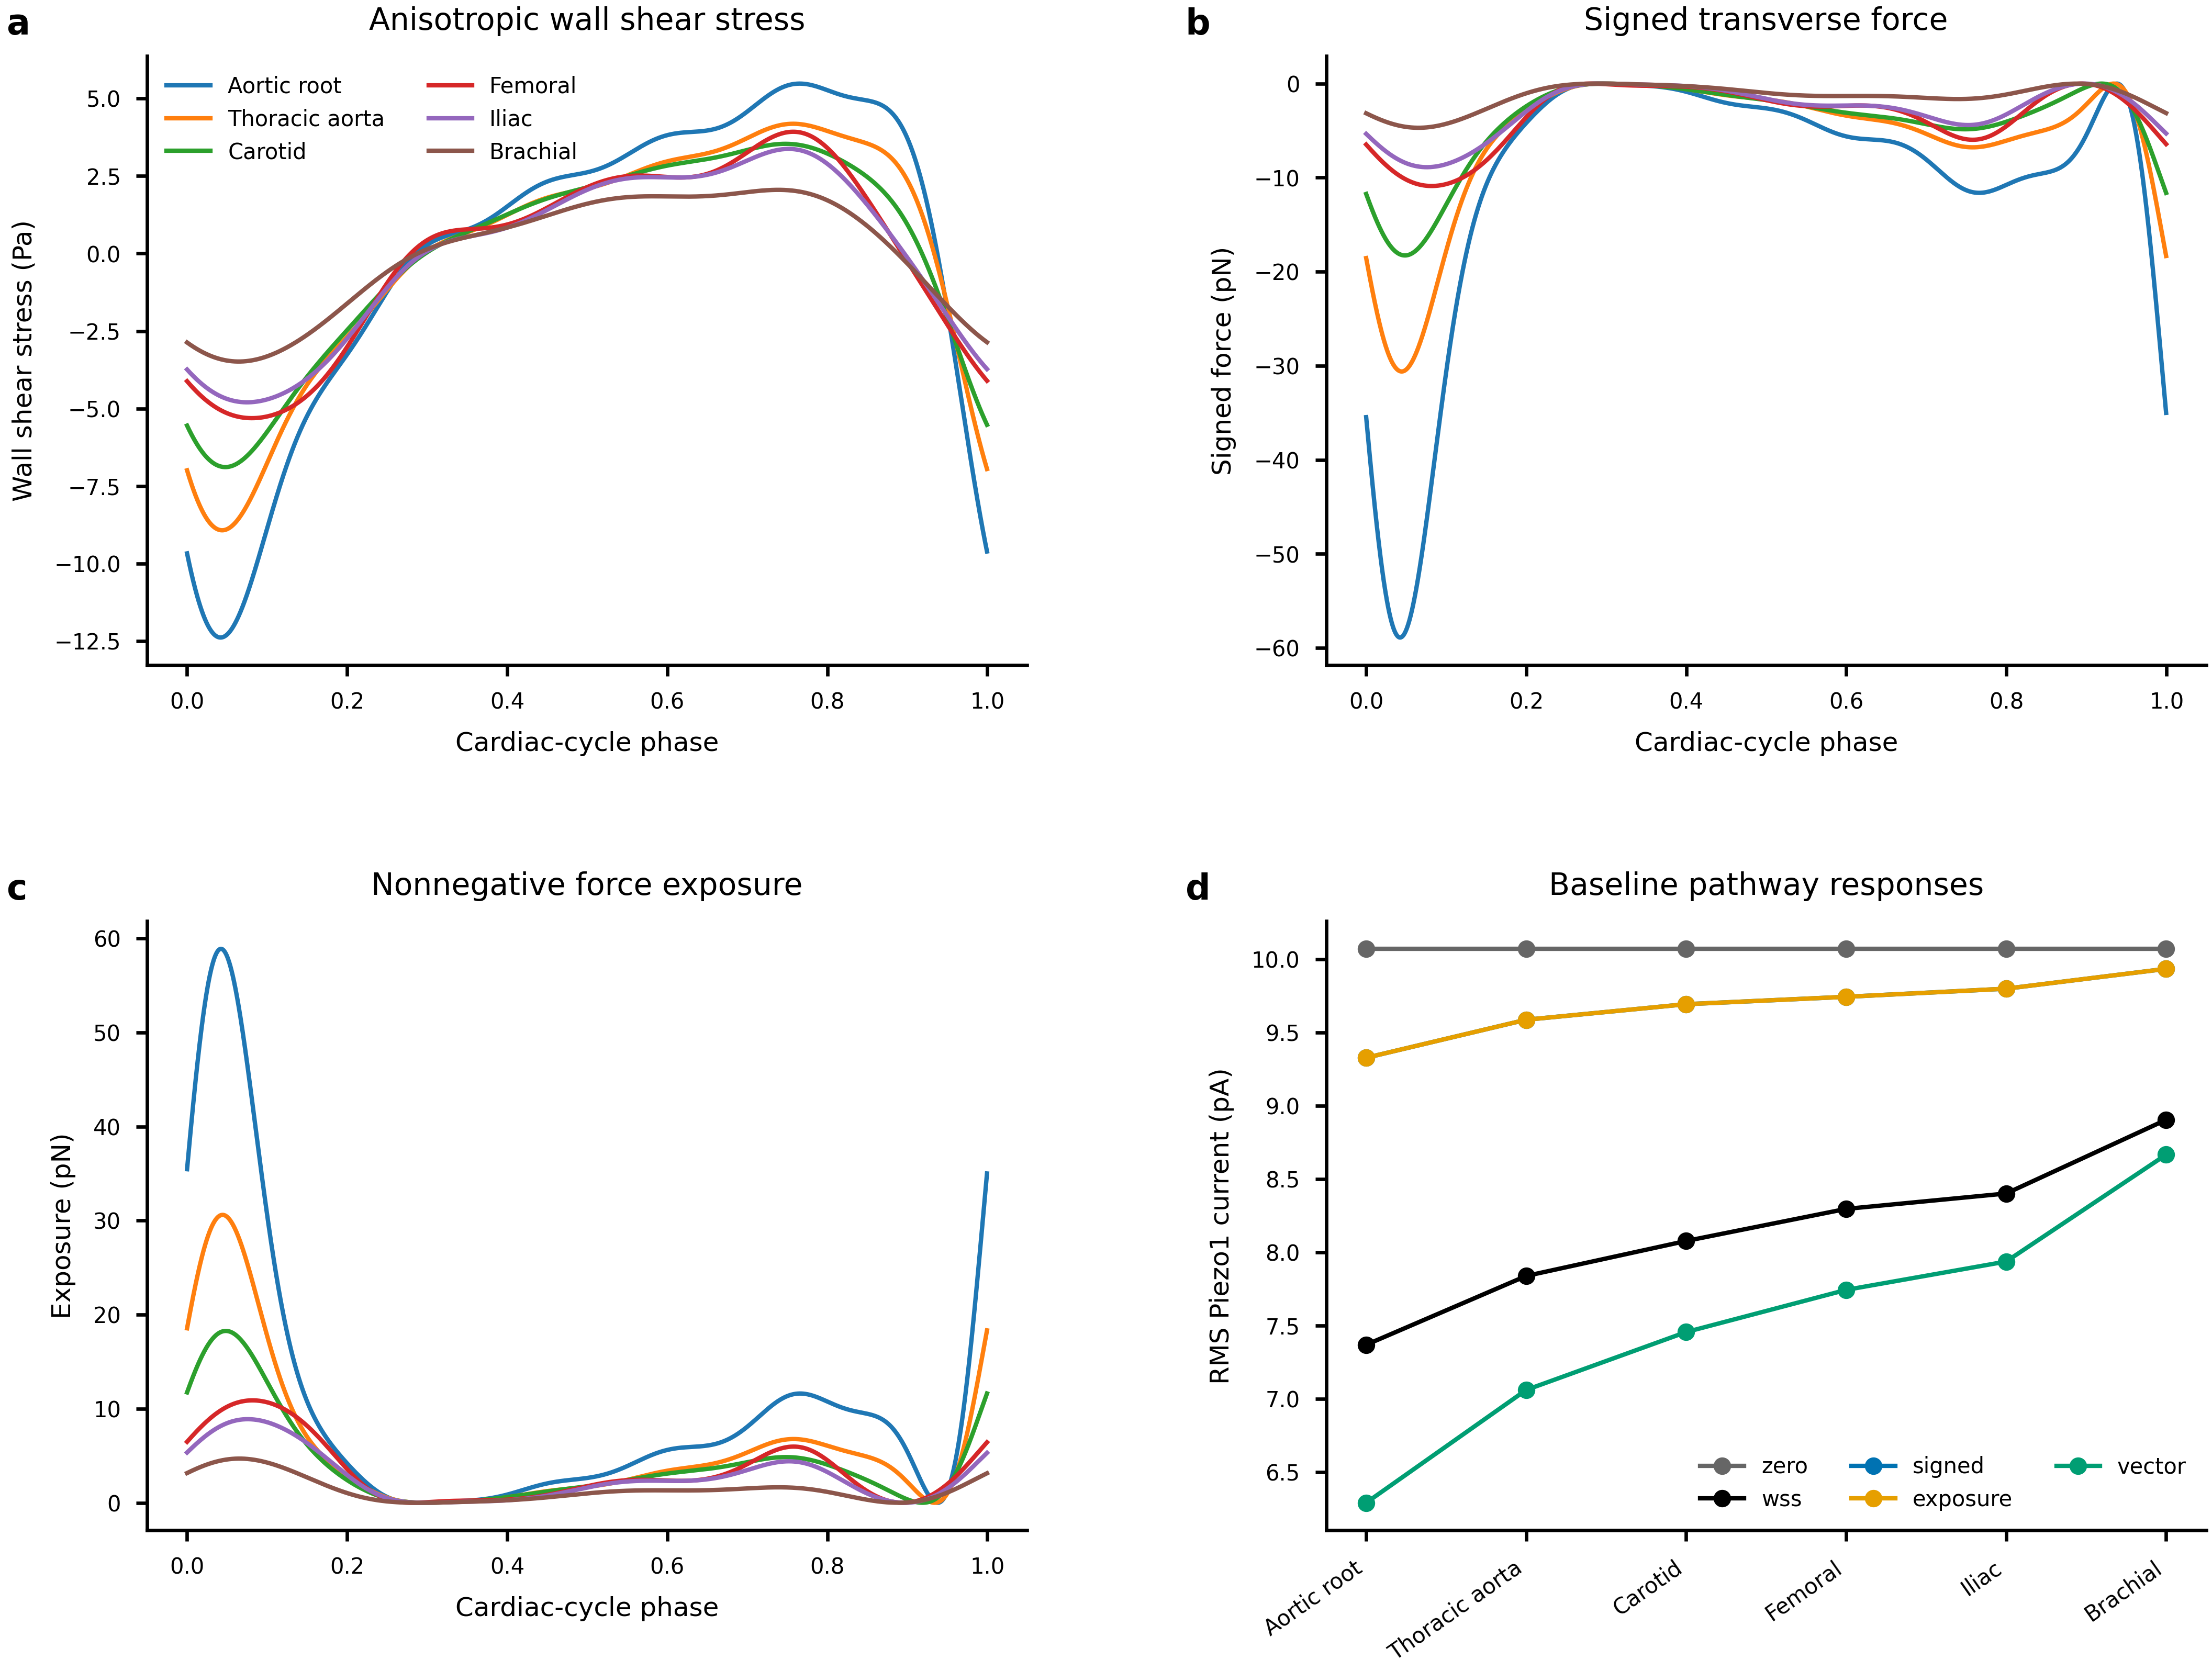

Figure_2_current_primary_assessment.png


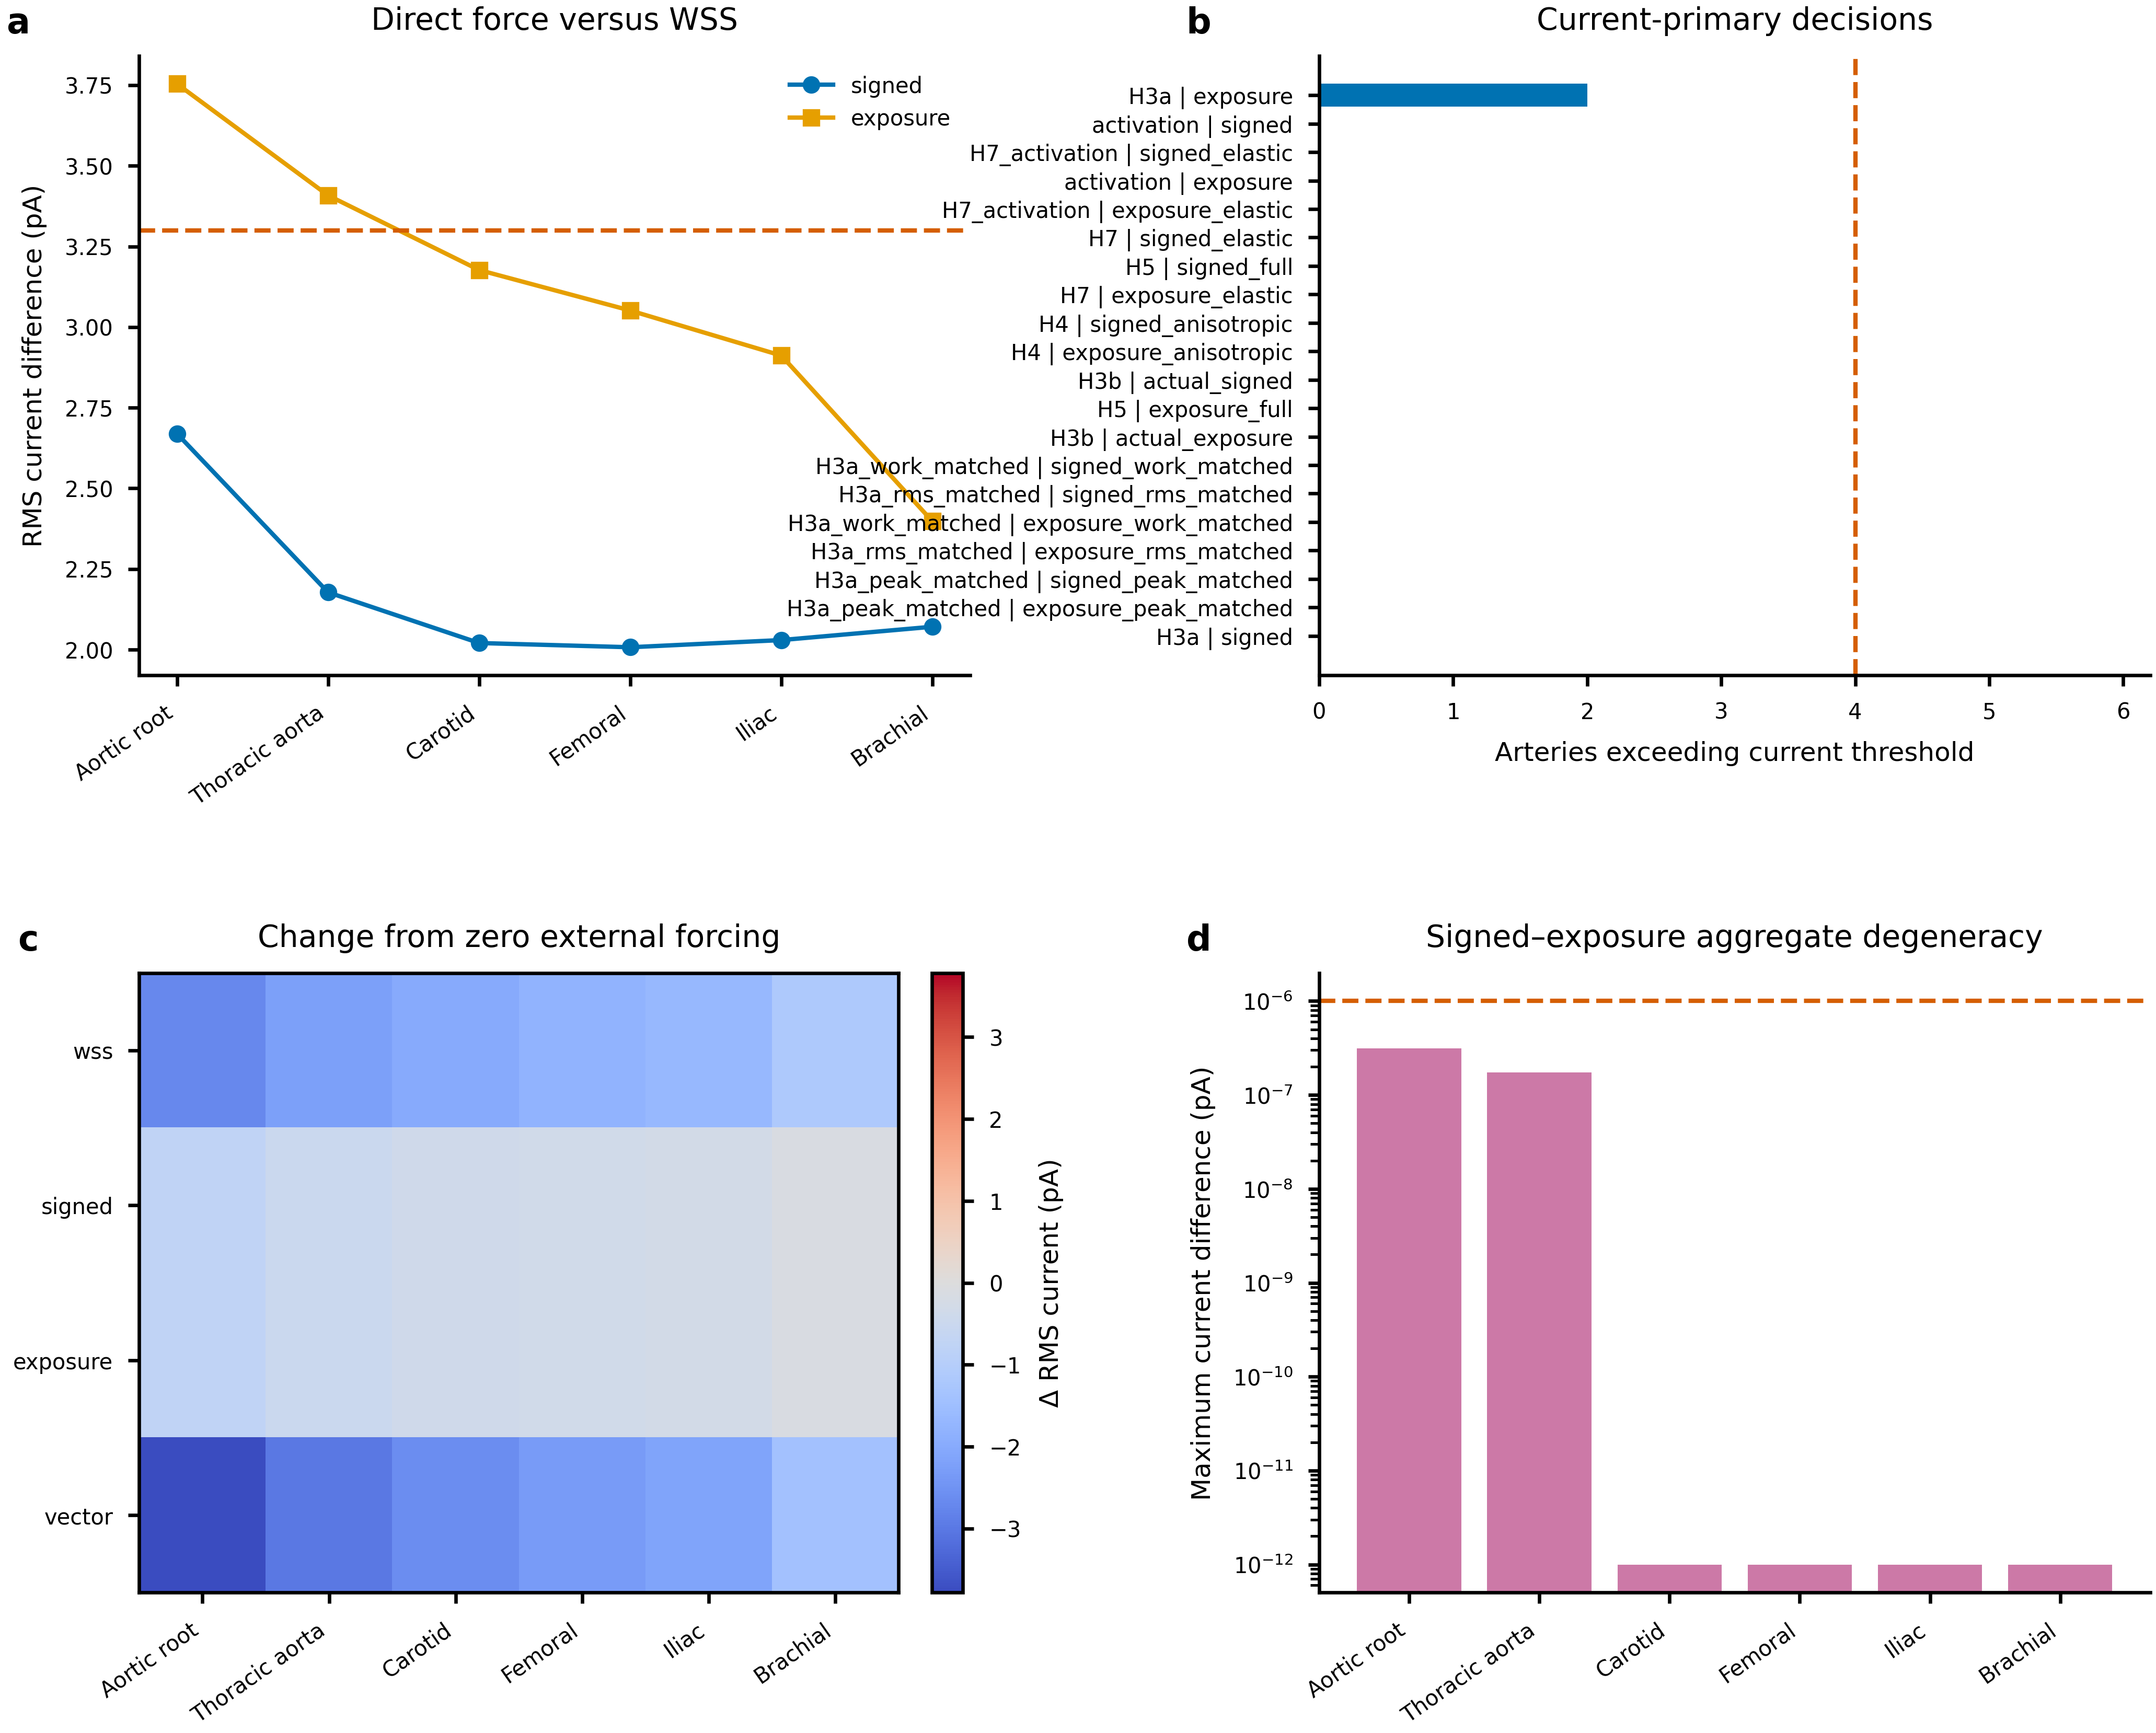

Figure_3_parametric_robustness.png


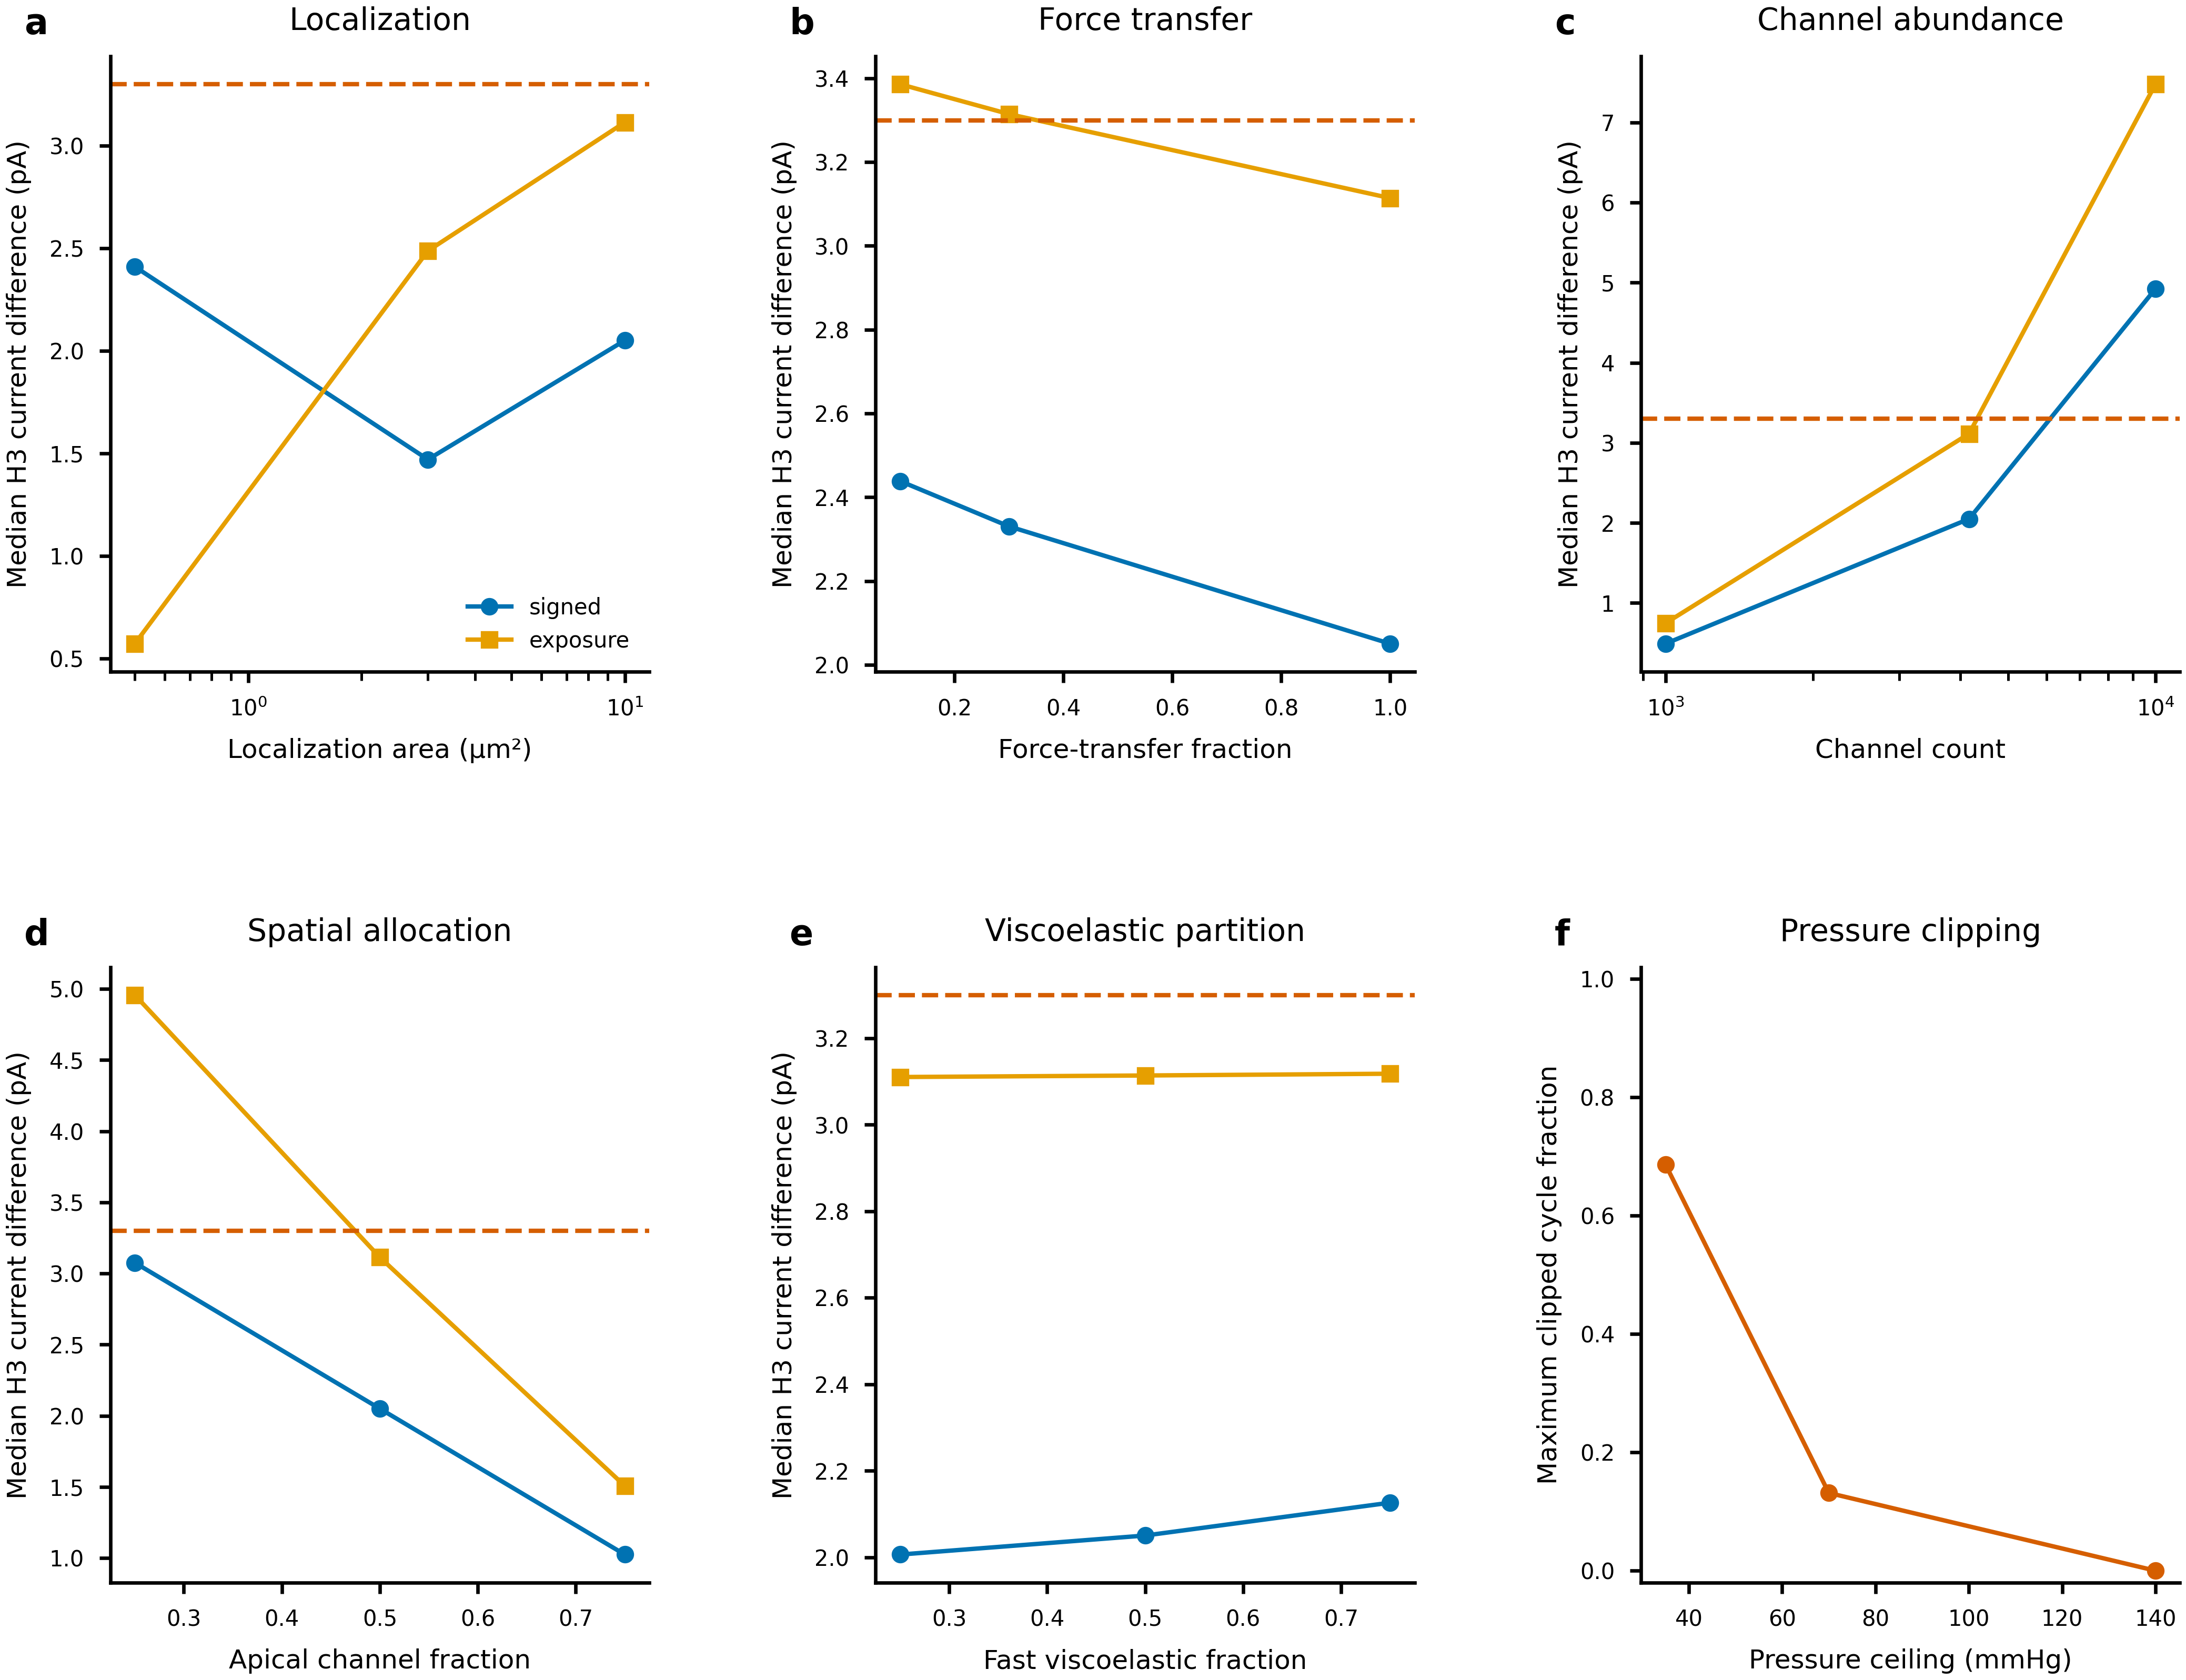

In [16]:
from IPython.display import Image, display

for figure_name in (
    "Figure_1_forcing_and_baseline_response.png",
    "Figure_2_current_primary_assessment.png",
    "Figure_3_parametric_robustness.png",
):
    print(figure_name)
    display(Image(filename=str(LOCAL_OUTPUT / "figures" / figure_name), width=1100))

## 10. Copy the complete immutable run to Google Drive

In [17]:
try:
    for child in LOCAL_OUTPUT.iterdir():
        destination = DRIVE_RUN_ROOT / child.name
        if child.is_dir():
            shutil.copytree(child, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(child, destination)
    shutil.copytree(LOCAL_LOGS, DRIVE_RUN_ROOT / "logs", dirs_exist_ok=True)
except Exception as error:
    record_failure("drive_copy", error)
    raise

## 11. Verify every archived checksum

In [18]:
checksum_records = json.loads((DRIVE_RUN_ROOT / "SHA256SUMS.json").read_text())
failures = []
for relative_name, record in checksum_records.items():
    path = DRIVE_RUN_ROOT / relative_name
    if not path.is_file():
        failures.append(f"missing: {relative_name}")
        continue
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != record["sha256"]:
        failures.append(f"checksum mismatch: {relative_name}")
if failures:
    raise RuntimeError("Archive verification failed:\n" + "\n".join(failures))
print(f"Verified {len(checksum_records):,} archived files.")

Verified 39 archived files.


## 12. Final summary

In [14]:
# Use local output since the drive copy hasn't run yet
manifest = json.loads((LOCAL_OUTPUT / "FINAL_MANIFEST.json").read_text())
assessment = json.loads((LOCAL_OUTPUT / "scientific_study" / "assessment" / "scientific_assessment.json").read_text())
print("=" * 76)
print("picoNewton_v4 full parametric production run completed")
print("=" * 76)
print("Run ID:", RUN_ID)
print("Repository commit:", resolved_commit)
print("Local output:", LOCAL_OUTPUT)
print("Status:", manifest["status"])
print("Study outcome:", manifest["study_outcome"])
print("Claims enabled:", manifest["claims_enabled"])
print("Parameter scenarios:", manifest["parameter_scenarios"])
print("Parametric artery rows:", manifest["parameter_artery_rows"])
print("Figure files:", len(manifest["figure_files"]))
print("Checksummed files:", manifest["checksummed_files"])
print("\nCompletion gates:")
for gate, passed in assessment["gates"].items():
    print(f"  {gate}: {passed}")

picoNewton_v4 full parametric production run completed
Run ID: 20260719_122432_UTC_62d4
Repository commit: ca89b2af7e9d161a24909d847ca168b91d2270c1
Local output: /content/picoNewton_v4_work/20260719_122432_UTC_62d4/production_output
Status: completed_with_claims_disabled
Study outcome: negative_under_current_parameterization
Claims enabled: False
Parameter scenarios: 13
Parametric artery rows: 78
Figure files: 13
Checksummed files: 39

Completion gates:
  anisotropy_increment_supported: False
  calibration_complete: False
  current_endpoint_has_predeclared_cross_artery_support: False
  direct_wss_distinction_supported: False
  endpoint_experimentally_calibrated: False
  held_out_wss_surrogate_supported: False
  independent_external_review_completed: False
  matched_load_controls_supported: False
  primary_pathways_free_of_pressure_clipping: False
  raw_hydrodynamic_forcing_archived: True
  signed_and_exposure_aggregate_outputs_distinguishable: False
  workflow_structural_validation: Tr